# Trusted vs Suspicious Product Detection
## Preprocessing & Labeling Notebook
---

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import re
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
df = pd.read_excel('/content/Trusted & Fake.xlsx')

## 2. Data Cleaning


In [ ]:
# ── Fix price double dot ──────────────────────────────
for col in ['price', 'original_price']:
    df[col] = df[col].astype(str).str.replace('..', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Fill missing prices with median per category ─────
df['price'] = df.groupby('category')['price'].transform(
    lambda x: x.fillna(x.median())
)
df['original_price'] = df['original_price'].fillna(df['price'])

# ── Fill missing text ─────────────────────────────────
df['description'] = df['description'].fillna('no description')
df['seller_name']  = df['seller_name'].fillna('unknown seller')

# ── Fill missing seller_rating with median ────────────
df['seller_rating'] = df['seller_rating'].fillna(df['seller_rating'].median())

# ── Calculate real discount ───────────────────────────
df['real_discount'] = ((df['original_price'] - df['price']) / df['original_price'] * 100)
df['real_discount'] = df['real_discount'].replace([np.inf, -np.inf], 0).fillna(0).clip(lower=0)

print('Shape after cleaning:', df.shape)
print('Missing values:')
print(df[['price','seller_rating','description','seller_name']].isnull().sum())

Shape after cleaning: (672, 20)
Missing values:
price            0
seller_rating    0
description      0
seller_name      0
dtype: int64


## 3. Remove Outliers

In [ ]:
# Remove extreme price outliers per category
def remove_outliers(group):
    Q1 = group['price'].quantile(0.05)
    Q3 = group['price'].quantile(0.95)
    return group[(group['price'] >= Q1) & (group['price'] <= Q3)]

df = df.groupby('category', group_keys=False).apply(remove_outliers).reset_index(drop=True)
print('Shape after removing outliers:', df.shape)

Shape after removing outliers: (600, 20)


/tmp/ipykernel_5726/2639378537.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('category', group_keys=False).apply(remove_outliers).reset_index(drop=True)


In [ ]:
# ── Text features ─────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)  # keep Arabic + English
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['title_clean']       = df['title'].apply(clean_text)
df['description_clean'] = df['description'].apply(clean_text)
df['combined_text']     = df['title_clean'] + ' ' + df['description_clean']

# ── Review features ───────────────────────────────────
suspicious_words = ['fake', 'scam', 'bad', 'poor', 'worst', 'broken',
                    'مش', 'سيء', 'وحش', 'مزيف', 'كوبي', 'تقليد']

def parse_reviews(x):
    try:
        reviews = ast.literal_eval(str(x))
        return ' '.join(reviews) if isinstance(reviews, list) else str(x)
    except:
        return str(x)

df['reviews_text'] = df['reviews'].apply(parse_reviews)
df['suspicious_words_count'] = df['reviews_text'].apply(
    lambda x: sum(w in str(x).lower() for w in suspicious_words)
)
df['review_length'] = df['reviews_text'].apply(lambda x: len(str(x).split()))

print('Features added ')
df[['title_clean', 'combined_text', 'suspicious_words_count', 'review_length']].head(7)

Features added 


,title_clean,combined_text,suspicious_words_count,review_length
0,oraimo spacebuds neo otw 323 true wireless ear...,oraimo spacebuds neo otw 323 true wireless ear...,1,182
1,soundcore k20i by anker semi in ear earbuds bl...,soundcore k20i by anker semi in ear earbuds bl...,1,42
2,soundcore r60i nc 6 mics real time anc adaptiv...,soundcore r60i nc 6 mics real time anc adaptiv...,1,48
3,soundcore by anker r50i true wireless earbuds ...,soundcore by anker r50i true wireless earbuds ...,0,0
4,soundcore by anker r50i nc true wireless earbu...,soundcore by anker r50i nc true wireless earbu...,0,0
5,oraimo otw 324 spacebuds lite true wireless ea...,oraimo otw 324 spacebuds lite true wireless ea...,0,0
6,anker soundcore vi r50i true wireless earbuds ...,anker soundcore vi r50i true wireless earbuds ...,1,178


## 5. Labeling Strategy

> **Note:** Since all data is from `amazon.eg` (a trusted source), we use **rule-based labeling** to simulate suspicious products based on known indicators of fraud and low quality.
>
> A product is labeled **Suspicious (1)** if it scores ≥ 2 out of 5 rules:
> - Low seller rating (below 25th percentile)
> - Low product rating (below 25th percentile)
> - Low seller reviews count (below 50th percentile)
> - High discount (above 75th percentile)
> - Suspicious words found in reviews

In [ ]:
# Thresholds based on data distribution
low_seller_rating    = df['seller_rating'].quantile(0.25)
low_product_rating   = df['product_rating'].quantile(0.25)
low_reviews_count    = df['seller_reviews_count'].quantile(0.50)
high_discount        = df['real_discount'].quantile(0.75)

print(f'Thresholds:')
print(f'  seller_rating    < {low_seller_rating}')
print(f'  product_rating   < {low_product_rating}')
print(f'  reviews_count    < {low_reviews_count}')
print(f'  real_discount    > {high_discount:.1f}%')

def create_label(row):
    score = 0
    if row['seller_rating']         < low_seller_rating:  score += 1
    if row['product_rating']        < low_product_rating: score += 1
    if row['seller_reviews_count']  < low_reviews_count:  score += 1
    if row['real_discount']         > high_discount:      score += 1
    if row['suspicious_words_count'] > 0:                 score += 1
    return 1 if score >= 2 else 0

df['label'] = df.apply(create_label, axis=1)

print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nSuspicious: {df["label"].sum()} ({df["label"].mean()*100:.1f}%)')
print(f'Trusted:    {(df["label"]==0).sum()} ({(df["label"]==0).mean()*100:.1f}%)')

Thresholds:
  seller_rating    < 4.0
  product_rating   < 3.4
  reviews_count    < 19.0
  real_discount    > 0.0%

Label distribution:
label
0    365
1    235
Name: count, dtype: int64

Suspicious: 235 (39.2%)
Trusted:    365 (60.8%)


## 6. Visualization

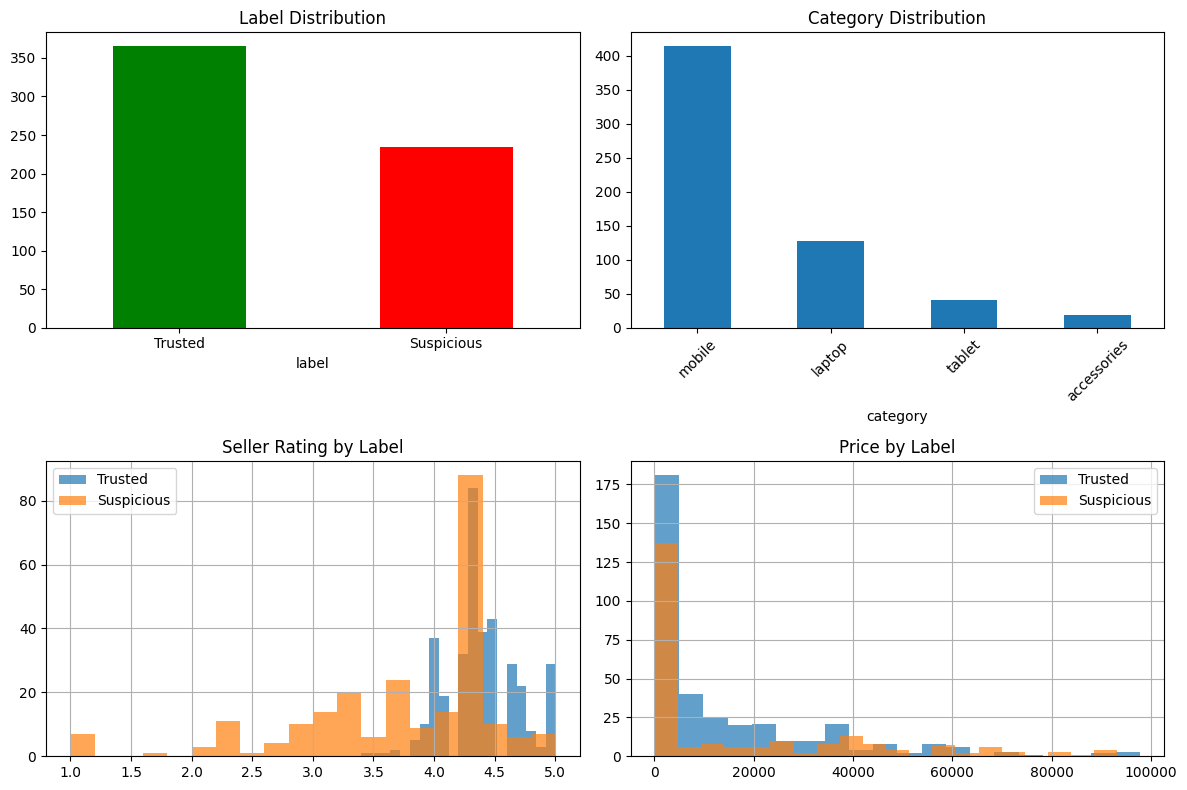

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Label distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Label Distribution')
axes[0,0].set_xticklabels(['Trusted', 'Suspicious'], rotation=0)

# Category distribution
df['category'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Category Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# Seller rating distribution
df.groupby('label')['seller_rating'].hist(ax=axes[1,0], alpha=0.7, bins=20)
axes[1,0].set_title('Seller Rating by Label')
axes[1,0].legend(['Trusted', 'Suspicious'])

# Price distribution
df.groupby('label')['price'].hist(ax=axes[1,1], alpha=0.7, bins=20)
axes[1,1].set_title('Price by Label')
axes[1,1].legend(['Trusted', 'Suspicious'])

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Final Dataset

In [ ]:
# Keep only the columns needed for the models
final_df = df[[
    'id', 'source', 'label', 'category',
    # Text Model
    'title_clean', 'description_clean', 'combined_text',
    # Image Model
    'image_url',
    # Price Model
    'price', 'original_price', 'real_discount',
    # Seller Model
    'seller_name', 'seller_rating', 'seller_reviews_count',
    # Review Model
    'product_rating', 'reviews_count',
    'reviews_text', 'suspicious_words_count', 'review_length'
]].copy()

print('Final dataset shape:', final_df.shape)
print('\nColumns per model:')
print('Text Model    :', ['title_clean', 'description_clean', 'combined_text'])
print('Image Model   :', ['image_url'])
print('Price Model   :', ['price', 'original_price', 'real_discount', 'category'])
print('Seller Model  :', ['seller_name', 'seller_rating', 'seller_reviews_count'])
print('Review Model  :', ['product_rating', 'reviews_count', 'suspicious_words_count'])
final_df.head()

Final dataset shape: (600, 19)

Columns per model:
Text Model    : ['title_clean', 'description_clean', 'combined_text']
Image Model   : ['image_url']
Price Model   : ['price', 'original_price', 'real_discount', 'category']
Seller Model  : ['seller_name', 'seller_rating', 'seller_reviews_count']
Review Model  : ['product_rating', 'reviews_count', 'suspicious_words_count']


,id,source,label,category,title_clean,description_clean,combined_text,image_url,price,original_price,real_discount,seller_name,seller_rating,seller_reviews_count,product_rating,reviews_count,reviews_text,suspicious_words_count,review_length
0,49,amazon.eg,1,accessories,oraimo spacebuds neo otw 323 true wireless ear...,bluetooth v5 4 stable connection latest blueto...,oraimo spacebuds neo otw 323 true wireless ear...,https://m.media-amazon.com/images/I/51NWfzTYFy...,598.98,648.00,7.564815,Visit the Oraimo Store,4.1,260,4.1,1,"[""بصراحه سماعه ممتازه ما شاء الله من جميع النو...",1,182
1,53,amazon.eg,1,accessories,soundcore k20i by anker semi in ear earbuds bl...,extended playtime enjoy up to 36 hours of musi...,soundcore k20i by anker semi in ear earbuds bl...,https://m.media-amazon.com/images/I/51GB8b4fc8...,680.00,680.00,0.000000,Visit the soundcore Store,3.6,3358,3.6,500,جودة كويسة جدا .صوت عالى .بيز محترم.قيمة مقابل...,1,42
2,54,amazon.eg,1,accessories,soundcore r60i nc 6 mics real time anc adaptiv...,real time adaptive noise cancelling advanced a...,soundcore r60i nc 6 mics real time anc adaptiv...,https://m.media-amazon.com/images/I/31JniANPxC...,1511.11,2333.00,35.228890,Brand: soundcore,3.8,38,3.8,300,الصراحه السماعه جميله و صوتها اعلى و انقى و ال...,1,48
3,55,amazon.eg,0,accessories,soundcore by anker r50i true wireless earbuds ...,soundcore is anker s audio brand our signature...,soundcore by anker r50i true wireless earbuds ...,https://m.media-amazon.com/images/I/51IZhggWfH...,898.99,898.99,0.000000,Brand: soundcore,4.1,361,4.1,200,,0,0
4,56,amazon.eg,0,accessories,soundcore by anker r50i nc true wireless earbu...,al powered calls 4 microphones custom al algor...,soundcore by anker r50i nc true wireless earbu...,https://m.media-amazon.com/images/I/61nwtLta29...,1359.00,1359.00,0.000000,Visit the Anker Store,4.1,1143,4.1,400,,0,0


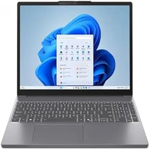

Title:  Lenovo IP Slim 15IRH8: Ci5-13420H, 8GB, 512GB SSD,
Price:  29777.0
Label:  🔴 Suspicious
----------------------------------------


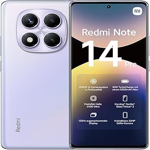

Title:  Xiaomi Redmi Note 14 Pro Smartphone, 8 + 256GB, Pu
Price:  12222.0
Label:  🔴 Suspicious
----------------------------------------


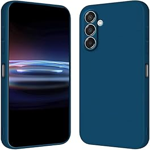

Title:  RankOne
Price:  1000.0
Label:  🟢 Trusted
----------------------------------------


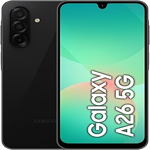

Title:  Samsung Galaxy A26 5G, Android Smartphone, 256GB S
Price:  15775.0
Label:  🟢 Trusted
----------------------------------------


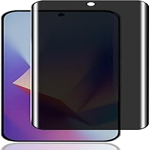

Title:  Jewloofa Privacy Screen Protector for Xiaomi Redmi
Price:  298.01
Label:  🔴 Suspicious
----------------------------------------


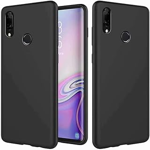

Title:  Gorilla Shop Liquid Silicone Phone Case Compatible
Price:  150.0
Label:  🔴 Suspicious
----------------------------------------


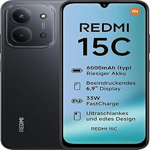

Title:  Xiaomi Redmi 15C Smartphone from 6 + 128 GB, Black
Price:  7111.0
Label:  🟢 Trusted
----------------------------------------


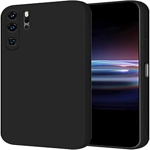

Title:  Case Compatible with Huawei P30 Pro / P30 Pro New 
Price:  150.0
Label:  🔴 Suspicious
----------------------------------------


In [ ]:
from IPython.display import display, Image
import requests
from PIL import Image as PILImage
from io import BytesIO

def show_products(df, n=5):
    sample = df.sample(n)
    for _, row in sample.iterrows():
        try:
            response = requests.get(row['image_url'], timeout=5)
            img = PILImage.open(BytesIO(response.content))
            img = img.resize((150, 150))
            display(img)
            print(f"Title:  {row['title'][:50]}")
            print(f"Price:  {row['price']}")
            print(f"Label:  {'🔴 Suspicious' if row['label'] == 1 else '🟢 Trusted'}")
            print("-" * 40)
        except:
            print(f"فشل تحميل الصورة: {row['image_url'][:50]}")

show_products(df, n=8)

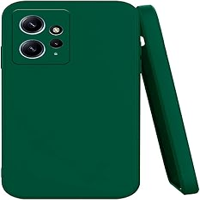

 ID                  : 56
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : mobile
 Title               : (Redmi Note 12 4G) Shockproof Liquid Silicone Back Case Cover with Fur Lined Interior and Full Camera Cover Compatible with Xiaomi Redmi Note 12 4G (Dark Green)
 Description         : High Quality Silicone High-end and fashionable look Complete Impact Protection...
 Price               : 100.0
 Original Price      : 100.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/51eD5yuQiRL._AC_UL320_.j...
 Seller Name         : Brand: Generic
 Seller Rating       : 3.0
 Seller Reviews Count: 3
 Product Rating      : 3.0
 Reviews Count       : 4
 Reviews             : خامه حلوه جدا ومش بيتخربش ومتوافق مع ريدمي نوت ١٢...
  Suspicious Words    : 1
 Review Length       : 10


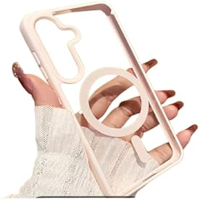

 ID                  : 43
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Clear Magnetic Case Compatible with Samsung Wireless Charging Support, Full ProtectionShockproof Transparent Cover with Strong Magnet Slim Design (Pink, Samsung Galaxy A35)
 Description         : WIDE COMPATIBILITY: Fits Samsung Galaxy A26, A56, A55, A54, A36, A35, A25, A16, A15, A06, A17, A07, and A12 models with precision cutouts. STRONG MAGN...
 Price               : 143.0
 Original Price      : 143.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/41q-CodcOjL._AC_UL320_.j...
 Seller Name         : Brand: فكرة
 Seller Rating       : 5.0
 Seller Reviews Count: 2
 Product Rating      : 5.0
 Reviews Count       : 0
 Reviews             : ...
  Suspicious Words    : 0
 Review Length       : 0


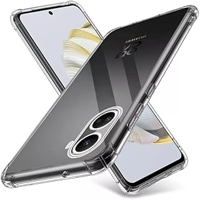

 ID                  : 87
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Zubitech
 Description         : Zubitech Huawei Nova 10 SE Clear Cover Case soft TPU Transparent Silicone Rubber Back Protective Case shock Absorbent Reinforced Corner for Huawei Nov...
 Price               : 120.0
 Original Price      : 120.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/51J-oK4NmWL._AC_UL320_.j...
 Seller Name         : Brand: Zubitech
 Seller Rating       : 5.0
 Seller Reviews Count: 5
 Product Rating      : 5.0
 Reviews Count       : 0
 Reviews             : Specially liked the extra padded corners....
  Suspicious Words    : 0
 Review Length       : 6


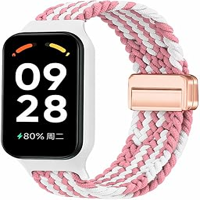

 ID                  : 71
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Dl3 Mobilak Nylon Braided Band Compatible with Redmi Smart Band 2 / Xiaomi Smart Band 8 Active, Magnetic Elastic Strap Soft Breathable Adjustable Wristband for Men Women
 Description         : Dl3 Mobilak Braided Nylon Watch Band is designed for comfort, style, and everyday performance. Crafted from premium woven nylon, this strap offers a s...
 Price               : 175.0
 Original Price      : 175.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/612Cf3+7+fL._AC_UL320_.j...
 Seller Name         : Brand: Dl3 Mobilak
 Seller Rating       : 4.0
 Seller Reviews Count: 2
 Product Rating      : 4.0
 Reviews Count       : 0
 Reviews             : ...
  Suspicious Words    : 0
 Review Length       : 0


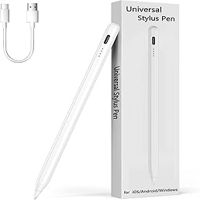

 ID                  : 39
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : mobile
 Title               : Aimery
 Description         : 【Compatibility】Stylus pens for Android/iPad/Pro/Air/Mini/iPhone/Lenovo/IOS/Samsung and Other Smartphone Devices. （Note:The products not for applicable...
 Price               : 240.0
 Original Price      : 281.0
  Discount            : 14.6%
  Image URL           : https://m.media-amazon.com/images/I/51JA2PptYEL._AC_UL320_.j...
 Seller Name         : Brand: Aimery
 Seller Rating       : 2.6
 Seller Reviews Count: 61
 Product Rating      : 2.6
 Reviews Count       : 200
 Reviews             : مش مناسب لتابلت المدرسة شغال ممتاز الصراحه وسعره اكتر من ممتاز سيء سيء سيء يوم يومين ورح يصير يعلق ومش راضين يجو يستلموه ويرجعوه...
  Suspicious Words    : 2
 Review Length       : 24


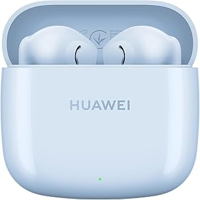

 ID                  : 70
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : mobile
 Title               : HUAWEI
 Description         : 【40-Hour Battery Life】Once fully charged, the earbuds will sustain up to 9 hours of listening, and when charged multiple times with the case, they can...
 Price               : 1170.0
 Original Price      : 1842.0
  Discount            : 36.5%
  Image URL           : https://m.media-amazon.com/images/I/61gP3AMqy2L._AC_UL320_.j...
 Seller Name         : Visit the HUAWEI Store
 Seller Rating       : 4.1
 Seller Reviews Count: 11999
 Product Rating      : 4.1
 Reviews Count       : 50
 Reviews             : ["سماعات Freebuds SE 2 مريحة جداً للبس لعدة ساعات، وبتفضل ثابتة فترة طويلة بشكل متوسط. مش هتوقع لو هزيت راسك جامد. كمان معاها تصنيف IP54 ضد المية، يعن...
  Suspicious Words    : 1
 Review Length       : 177


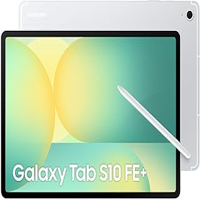

 ID                  : 34
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Samsung
 Description         : Wide and Bright Display: Enjoy a 13.1" display on the Galaxy Tab S10 FE+, the largest screen ever seen on a Galaxy Tab FE device. Power and Performanc...
 Price               : 34656.0
 Original Price      : 34656.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/51J7k1m6wiL._AC_UL320_.j...
 Seller Name         : Visit the Samsung Store
 Seller Rating       : 4.7
 Seller Reviews Count: 485
 Product Rating      : 4.7
 Reviews Count       : 2
 Reviews             : Excelente adquisición, la uso más que nada para jugar a distancia con mi play5 y va de maravilla, la uso tambien para otras actividades referentes a l...
  Suspicious Words    : 0
 Review Length       : 108


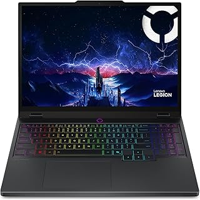

 ID                  : 34
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : laptop
 Title               : Lenovo Legion 5 15IRX10 Intel Core™ i7-13650HX, 16GB RAM, 1TB SSD, RTX™ 5060 8GB GDDR7, 15.1" WQXGA (2560x1600) OLED, 165Hz, Free DOS, 3 Years Warranty, 83LY00PCED
 Description         : AI-Powered Gaming PC NVIDIA GeForce RTX 5060 8GB GDDR7, Boost Clock 2497MHz, TGP 115W, 572 AI TOPS 16GB SODIMM DDR5-4800 1TB SSD M.2 2242 PCIe 4.0x4 N...
 Price               : 79999.0
 Original Price      : 79999.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/71FDjdybCJL._AC_UL320_.j...
 Seller Name         : Visit the Lenovo Store
 Seller Rating       : 4.3
 Seller Reviews Count: 0
 Product Rating      : 0.0
 Reviews Count       : 3
 Reviews             : ...
  Suspicious Words    : 0
 Review Length       : 0


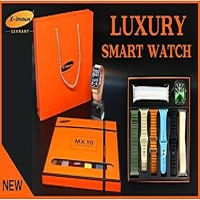

 ID                  : 28
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : mobile
 Title               : X-Inova Germany MX 10 Smart Watch with 7 fashionable watch straps and Always on Clock - Gold
 Description         : Capture festive moments with 'Shake to Take Photo', and stay connected with Bluetooth calls. Prioritize wellness with health monitoring and enjoy musi...
 Price               : 1250.0
 Original Price      : 1250.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/716fr-zjl7L._AC_UL320_.j...
 Seller Name         : Brand: X-Inova Germany
 Seller Rating       : 3.4
 Seller Reviews Count: 12
 Product Rating      : 3.4
 Reviews Count       : 1
 Reviews             : جميلة جدا ولله شحنتها مرة وبقالها٦ايام والبطارية ماليانه زي ماهي لا تظهر اسم المتصل البلوتوث بيفصل لوحده كل شويه ليست كل الالوان اللي في الصوره شحن لم...
  Suspicious Words    : 0
 Review Length       : 29


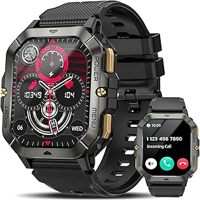

 ID                  : 88
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Military Smart Watches for Men (Answer/Make Calls), 2.02'' Fitness Smart Watch for Android and iPhone, Waterproof Fitness Tracker with Blood Pressure/Heart Rate/Sleep/100+ Sport Modes, Watches for Men
 Description         : OUTDOOR ADVENTURE WITH YOU - This military outdoor smartwatch is made of special composite material and sturdy aluminum alloy bezel, which has gone th...
 Price               : 6489.0
 Original Price      : 6489.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/71uBDO3fJoL._AC_UL320_.j...
 Seller Name         : Brand: DEKELIFE
 Seller Rating       : 4.1
 Seller Reviews Count: 1582
 Product Rating      : 4.1
 Reviews Count       : 0
 Reviews             : ...
  Suspicious Words    : 0
 Review Length       : 0


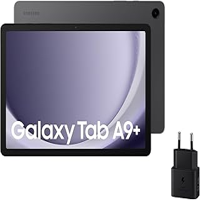

 ID                  : 5
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : Samsung
 Description         : Hardware interface: microSD Memory storage capacity: 128.0 GB Display size: 11.0 inches Total USB ports: 1.0...
 Price               : 14944.0
 Original Price      : 14944.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/61GPzXYPmUL._AC_UL320_.j...
 Seller Name         : Visit the Samsung Store
 Seller Rating       : 4.3
 Seller Reviews Count: 454
 Product Rating      : 4.3
 Reviews Count       : 2
 Reviews             : Very good tablet and it comes with the charger I bought it for my son and he likes it allot I was genuinely impressed with how well this item was pack...
  Suspicious Words    : 0
 Review Length       : 107


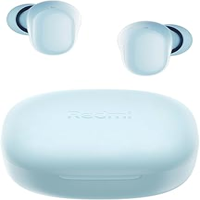

 ID                  : 63
 Source              : amazon.eg
  Label               : 🔴 Suspicious
 Category            : mobile
 Title               : Redmi Buds 6 Play - In-Ear Headphones, 36h Battery Life, 10 mm Dynamic Driver with 4 EQ Settings, AI Noise Cancelling for Calls, Bluetooth 5.4, Quick Charging, Blue|6 month manufacturer warranty
 Description         : 36 Hours Battery Life - Long lasting use with charging box, ideal for daily use and longer uses without constant charging. 10 mm dynamic driver: deliv...
 Price               : 748.95
 Original Price      : 855.0
  Discount            : 12.4%
  Image URL           : https://m.media-amazon.com/images/I/41zMABLtRzL._AC_UL320_.j...
 Seller Name         : Visit the Xiaomi Store
 Seller Rating       : 4.0
 Seller Reviews Count: 19605
 Product Rating      : 4.0
 Reviews Count       : 200
 Reviews             : ["اير بودز ممتازة حرفيا ...الصوت عالي بشكل معقول بحيث لا يؤذي الاذن ، مع ملاحظة ان السماعة الشمال صوته اعلي من السماعة اليم

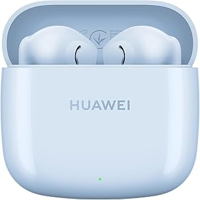

 ID                  : 59
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : HUAWEI FreeBuds SE 2, 40-Hour Battery Life, Compact and Comfortable to Grip, 3 Hours of Music Playback on a 10-Minute Charge, IP54 Dust & Splash Resistance, Isle Blue
 Description         : no description...
 Price               : 1170.0
 Original Price      : 1170.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/61gP3AMqy2L._AC_UL320_.j...
 Seller Name         : unknown seller
 Seller Rating       : 4.3
 Seller Reviews Count: 0
 Product Rating      : 4.1
 Reviews Count       : 50
 Reviews             : ...
  Suspicious Words    : 0
 Review Length       : 0


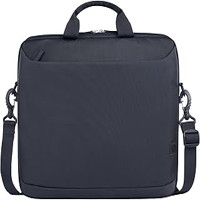

 ID                  : 21
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : laptop
 Title               : HP Everyday - 14 inch Laptop Briefcase - A08JSAA - Odyssey Gray
 Description         : HP Everyday - 14 inch Laptop Briefcase - A08JSAA - Odyssey Gray...
 Price               : 1639.0
 Original Price      : 1639.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/810GIaR5WpL._AC_UL320_.j...
 Seller Name         : Visit the HP Store
 Seller Rating       : 4.7
 Seller Reviews Count: 15
 Product Rating      : 4.7
 Reviews Count       : 0
 Reviews             : Excellent choice for slim laptops 14 inch max Good quality, compact size but fit accessory as well Just what I needed.  Very high quality roomy and a ...
  Suspicious Words    : 0
 Review Length       : 41


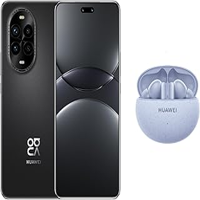

 ID                  : 50
 Source              : amazon.eg
  Label               : 🟢 Trusted
 Category            : mobile
 Title               : HUAWEI
 Description         : Sleek & Premium Design – Crafted for elegance and comfort, the Huawei nova 13 Pro features a slim, lightweight body with a stunning finish, making it ...
 Price               : 33119.0
 Original Price      : 33119.0
  Discount            : 0.0%
  Image URL           : https://m.media-amazon.com/images/I/71W4tcqvddL._AC_UL320_.j...
 Seller Name         : Visit the HUAWEI Store
 Seller Rating       : 4.2
 Seller Reviews Count: 12
 Product Rating      : 4.2
 Reviews Count       : 2
 Reviews             : موبايل رااااااااائع شكرا امازون وافضل سعر بلا منافس It’s like iPhone stable and speed with very good camera with suitable price and outstanding perfor...
  Suspicious Words    : 0
 Review Length       : 50


In [ ]:
from IPython.display import display
from PIL import Image as PILImage
from io import BytesIO
import requests
import pandas as pd

def show_full_product(row):
    print("=" * 60)

    # الصورة
    try:
        response = requests.get(row['image_url'], timeout=5)
        img = PILImage.open(BytesIO(response.content)).resize((200, 200))
        display(img)
    except:
        print(" failed loaded")

    # كل الـ columns
    print(f" ID                  : {row['id']}")
    print(f" Source              : {row['source']}")
    print(f"  Label               : {'🔴 Suspicious' if row['label'] == 1 else '🟢 Trusted'}")
    print(f" Category            : {row['category']}")
    print(f" Title               : {row['title']}")
    print(f" Description         : {str(row['description'])[:150]}...")
    print(f" Price               : {row['price']}")
    print(f" Original Price      : {row['original_price']}")
    print(f"  Discount            : {row['real_discount']:.1f}%")
    print(f"  Image URL           : {str(row['image_url'])[:60]}...")
    print(f" Seller Name         : {row['seller_name']}")
    print(f" Seller Rating       : {row['seller_rating']}")
    print(f" Seller Reviews Count: {row['seller_reviews_count']}")
    print(f" Product Rating      : {row['product_rating']}")
    print(f" Reviews Count       : {row['reviews_count']}")
    print(f" Reviews             : {str(row['reviews_text'])[:150]}...")
    print(f"  Suspicious Words    : {row['suspicious_words_count']}")
    print(f" Review Length       : {row['review_length']}")
    print("=" * 60)

# عرض 5 منتجات عشوائية
for _, row in df.sample(15).iterrows():
    show_full_product(row)